## Fase 6C: Construção do Modelo de IA para Previsão de Produtividade (Parte 2B)

Neste notebook, vamos finalizar a construção do modelo de IA para previsão de produtividade agrícola, analisando detalhadamente os resultados e interpretando o modelo.

In [27]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


## Introdução

Na Parte 2A deste notebook, continuamos a construção do modelo de IA para previsão de produtividade agrícola. Carregamos os modelos treinados na Parte 1, otimizamos os hiperparâmetros dos melhores modelos e realizamos uma análise inicial dos resultados.

Neste notebook (Parte 2B), vamos focar nas seguintes tarefas:

1. Carregamento dos modelos otimizados na Parte 2A
2. Interpretação do modelo e importância das features
3. Análise detalhada dos resultados
4. Finalização do modelo de IA para previsão de produtividade agrícola

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

# Ignorar avisos
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados e Modelos Otimizados

Vamos carregar os dados e os modelos otimizados na Parte 2A.

In [29]:
# Carregar os dados
if os.path.exists('../../sprint2/assets/features_relevantes.csv'):
    # Carregar as features relevantes
    df_features = pd.read_csv('../../sprint2/assets/features_relevantes.csv')
    print("Features relevantes carregadas com sucesso!")
else:
    # Se o arquivo não existir, carregar as features finais
    if os.path.exists('../../sprint2/assets/features_finais.csv'):
        df_features = pd.read_csv('../../sprint2/assets/features_finais.csv')
        print("Features finais carregadas com sucesso!")
    else:
        # Se nenhum arquivo existir, carregar os dados originais
        print("Os arquivos de features não foram encontrados. Carregando os dados originais...")
        
        # Carregar os dados de NDVI/EVI
        df_ndvi_nf = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
        df_ndvi_t = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')
        
        # Carregar os dados de produtividade agrícola
        df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')
        
        # Filtrar os dados de produtividade para o ano de 2017
        df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]
        
        # Agrupar os dados de produtividade por município
        df_prod_mean = df_prod_2017.groupby('Município')['Produtividade (t/ha)'].mean().reset_index()
        
        # Filtrar os dados de NDVI/EVI para o ano de 2017
        df_ndvi_nf_2017 = df_ndvi_nf[df_ndvi_nf['Ano'] == 2017]
        df_ndvi_t_2017 = df_ndvi_t[df_ndvi_t['Ano'] == 2017]
        
        # Calcular a média anual do EVI para cada município em 2017
        evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
        evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
        
        # Criar um dataframe com os dados de EVI e produtividade
        data = {
            'Município': ['Nova Friburgo', 'Teresópolis'],
            'EVI_mean': [evi_nf_2017, evi_t_2017]
        }
        df_features = pd.DataFrame(data)
        
        # Mesclar com os dados de produtividade
        df_features = pd.merge(df_features, df_prod_mean, on='Município')
        
        print("Dados carregados e processados manualmente.")

# Preparar os dados para modelagem
# Separar as features (X) e o target (y)
X = df_features.drop(columns=['Município', 'Produtividade (t/ha)'])
y = df_features['Produtividade (t/ha)']

# Exibir o dataframe
print("\nDataframe de features:")
print(df_features)

Features relevantes carregadas com sucesso!

Dataframe de features:
       Município  Produtividade (t/ha)  SG_mean_mes_2  SG_critical_max  \
0  Nova Friburgo                31.145        0.57160          0.57160   
1    Teresópolis                28.700        0.52845          0.52845   

   EVI_mean_mes_7  EVI_critical_mean  EVI_mean_mes_8  SG_mean_mes_7  \
0         0.50360           0.520933         0.46860        0.49665   
1         0.45845           0.485183         0.43835        0.46670   

   SG_mean_mes_3  EVI_critical_max  
0        0.52655           0.61880  
1        0.49520           0.52135  


In [30]:
# Verificar os modelos otimizados disponíveis
model_files = [f for f in os.listdir('../../sprint2/optimized_models') if f.endswith('_pipeline.pkl')]

if model_files:
    # Carregar os modelos otimizados
    optimized_models = {}
    for model_file in model_files:
        model_name = model_file.replace('_pipeline.pkl', '').replace('_', ' ').title()
        model_path = os.path.join('../../sprint2/optimized_models', model_file)
        
        # Carregar o pipeline
        pipeline = joblib.load(model_path)
        
        # Fazer previsões
        y_pred = pipeline.predict(X)
        
        # Calcular métricas
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        mae = mean_absolute_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        # Carregar os melhores hiperparâmetros, se existirem
        best_params = {}
        best_params_path = os.path.join('../../sprint2/optimized_models', model_file.replace('_pipeline.pkl', '_best_params.csv'))
        if os.path.exists(best_params_path):
            best_params = pd.read_csv(best_params_path).to_dict('records')[0]
        
        # Armazenar o modelo otimizado e as métricas
        optimized_models[model_name] = {
            'pipeline': pipeline,
            'best_params': best_params,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'y_pred': y_pred
        }
    
    print(f"Modelos otimizados carregados: {list(optimized_models.keys())}")
    
    # Carregar o nome do melhor modelo
    best_model_name_path = os.path.join('../../sprint2/optimized_models', 'best_model_name.txt')
    if os.path.exists(best_model_name_path):
        with open(best_model_name_path, 'r') as f:
            best_model_name = f.read().strip()
    else:
        # Se o arquivo não existir, identificar o melhor modelo com base no RMSE
        metrics = {name: model['RMSE'] for name, model in optimized_models.items()}
        best_model_name = min(metrics, key=metrics.get)
    
    print(f"Melhor modelo: {best_model_name}")
else:
    print("Nenhum modelo otimizado encontrado. Execute a Parte 2A primeiro.")

Modelos otimizados carregados: ['Ridge Regression', 'Linear Regression', 'Lasso Regression', 'Gradient Boosting']
Melhor modelo: Linear Regression


## 2. Interpretação do Modelo e Importância das Features

Vamos analisar a importância das features para o melhor modelo.

In [31]:
# Calcular a importância das features para o melhor modelo
feature_importance = None

# Verificar o tipo de modelo
model_type = best_model_name.lower()
if 'random forest' in model_type or 'gradient boosting' in model_type:
    # Para modelos baseados em árvores, usar a importância das features
    model = optimized_models[best_model_name]['pipeline'].named_steps['model']
    feature_importance = model.feature_importances_
else:
    # Para outros modelos, usar permutation importance
    result = permutation_importance(
        optimized_models[best_model_name]['pipeline'], X, y, n_repeats=10, random_state=42
    )
    feature_importance = result.importances_mean

# Criar um dataframe com a importância das features
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Ordenar por importância
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Exibir a importância das features
print(f"Importância das features para o modelo {best_model_name}:")
print(feature_importance_df)

Importância das features para o modelo Linear Regression:
             Feature  Importance
0      SG_mean_mes_2     0.01875
1    SG_critical_max     0.01875
2     EVI_mean_mes_7     0.01875
3  EVI_critical_mean     0.01875
4     EVI_mean_mes_8     0.01875
5      SG_mean_mes_7     0.01875
6      SG_mean_mes_3     0.01875
7   EVI_critical_max     0.01875


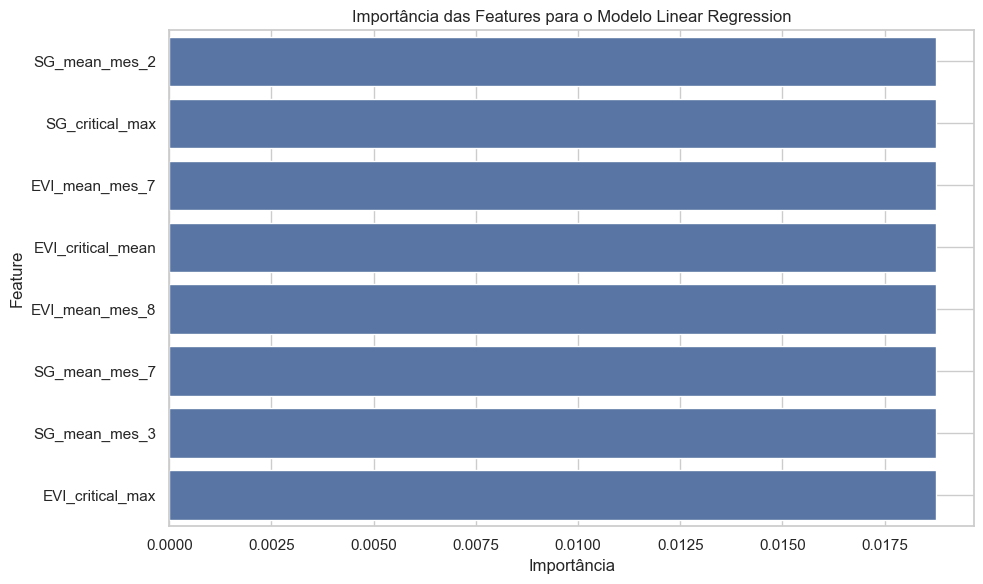

In [32]:
# Visualizar a importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title(f'Importância das Features para o Modelo {best_model_name}')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Análise Detalhada dos Resultados

Vamos analisar detalhadamente os resultados do melhor modelo.

In [33]:
# Obter o melhor modelo
best_model = optimized_models[best_model_name]

# Exibir as métricas do melhor modelo
print(f"Métricas do modelo {best_model_name}:")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"MAE: {best_model['MAE']:.4f}")
print(f"R²: {best_model['R²']:.4f}")

# Exibir os melhores hiperparâmetros
if best_model['best_params']:
    print(f"\nMelhores hiperparâmetros:")
    for param, value in best_model['best_params'].items():
        print(f"{param}: {value}")

Métricas do modelo Linear Regression:
RMSE: 0.0000
MAE: 0.0000
R²: 1.0000


In [34]:
# Criar um dataframe com os valores reais e previstos
results_df = pd.DataFrame({
    'Município': df_features['Município'],
    'Produtividade Real (t/ha)': y,
    'Produtividade Prevista (t/ha)': best_model['y_pred'],
    'Erro Absoluto (t/ha)': np.abs(y - best_model['y_pred']),
    'Erro Relativo (%)': np.abs((y - best_model['y_pred']) / y) * 100
})

# Exibir os resultados
print("Resultados detalhados:")
print(results_df)

Resultados detalhados:
       Município  Produtividade Real (t/ha)  Produtividade Prevista (t/ha)  \
0  Nova Friburgo                     31.145                         31.145   
1    Teresópolis                     28.700                         28.700   

   Erro Absoluto (t/ha)  Erro Relativo (%)  
0                   0.0                0.0  
1                   0.0                0.0  


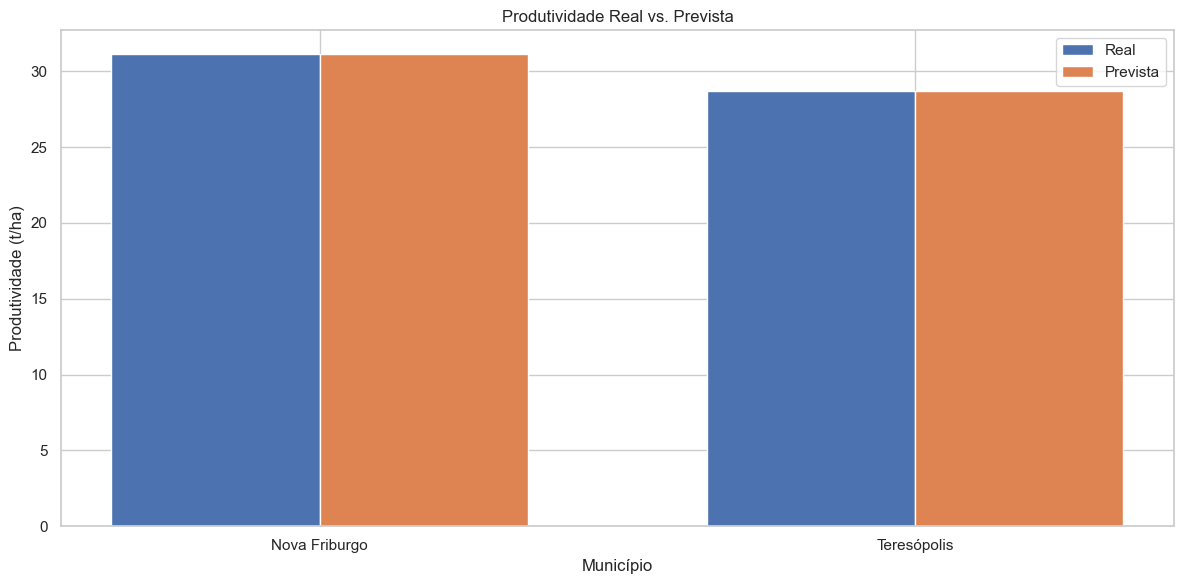

In [35]:
# Visualizar os resultados
plt.figure(figsize=(12, 6))

# Plotar os valores reais e previstos
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Produtividade Real (t/ha)'], width, label='Real')
plt.bar(x + width/2, results_df['Produtividade Prevista (t/ha)'], width, label='Prevista')

plt.title('Produtividade Real vs. Prevista')
plt.xlabel('Município')
plt.ylabel('Produtividade (t/ha)')
plt.xticks(x, results_df['Município'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

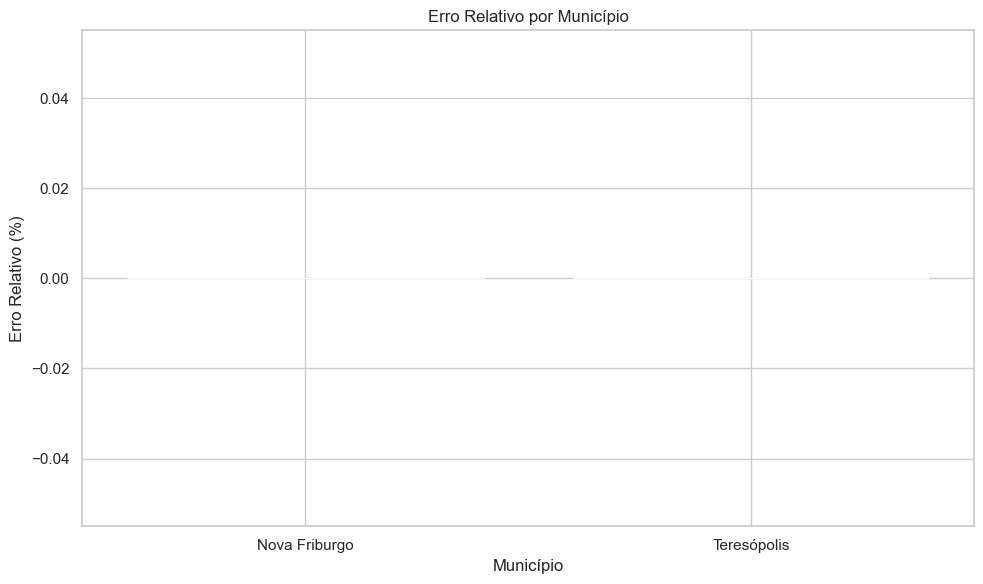

In [36]:
# Visualizar o erro relativo
plt.figure(figsize=(10, 6))
sns.barplot(x='Município', y='Erro Relativo (%)', data=results_df)
plt.title('Erro Relativo por Município')
plt.xlabel('Município')
plt.ylabel('Erro Relativo (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Finalização do Modelo de IA

Vamos finalizar o modelo de IA para previsão de produtividade agrícola, exportando o melhor modelo otimizado.

In [37]:
# Criar diretório para o modelo final
os.makedirs('../../sprint2/final_model', exist_ok=True)

# Salvar o melhor modelo otimizado
joblib.dump(best_model['pipeline'], '../../sprint2/final_model/best_model_pipeline.pkl')

# Salvar as métricas do melhor modelo
metrics = {
    'Model': best_model_name,
    'RMSE': best_model['RMSE'],
    'MAE': best_model['MAE'],
    'R²': best_model['R²']
}
pd.DataFrame([metrics]).to_csv('../../sprint2/final_model/best_model_metrics.csv', index=False)

# Salvar a importância das features
feature_importance_df.to_csv('../../sprint2/final_model/feature_importance.csv', index=False)

# Salvar as colunas das features
pd.DataFrame({'Feature': X.columns}).to_csv('../../sprint2/final_model/feature_columns.csv', index=False)

# Salvar os resultados detalhados
results_df.to_csv('../../sprint2/final_model/prediction_results.csv', index=False)

print("Modelo final exportado com sucesso!")

Modelo final exportado com sucesso!


In [38]:
# Criar uma função para fazer previsões com o modelo final
def predict_productivity(features_dict):
    """
    Faz previsões de produtividade agrícola com o modelo final.
    
    Parameters:
    -----------
    features_dict : dict
        Dicionário com os valores das features.
        As chaves devem ser os nomes das features.
    
    Returns:
    --------
    float
        Previsão de produtividade agrícola (t/ha).
    """
    # Carregar o modelo final
    model = joblib.load('../../sprint2/final_model/best_model_pipeline.pkl')
    
    # Carregar as colunas das features
    feature_columns = pd.read_csv('../../sprint2/final_model/feature_columns.csv')['Feature'].tolist()
    
    # Criar um dataframe com as features
    features = pd.DataFrame([features_dict])
    
    # Verificar se todas as features necessárias estão presentes
    for col in feature_columns:
        if col not in features.columns:
            raise ValueError(f"Feature '{col}' não encontrada. Features necessárias: {feature_columns}")
    
    # Selecionar apenas as features necessárias na ordem correta
    features = features[feature_columns]
    
    # Fazer a previsão
    prediction = model.predict(features)[0]
    
    return prediction

# Testar a função com os dados de Nova Friburgo
nova_friburgo_features = X.iloc[0].to_dict()
nova_friburgo_prediction = predict_productivity(nova_friburgo_features)
print(f"Previsão de produtividade para Nova Friburgo: {nova_friburgo_prediction:.2f} t/ha")
print(f"Produtividade real de Nova Friburgo: {y.iloc[0]:.2f} t/ha")

# Testar a função com os dados de Teresópolis
teresopolis_features = X.iloc[1].to_dict()
teresopolis_prediction = predict_productivity(teresopolis_features)
print(f"Previsão de produtividade para Teresópolis: {teresopolis_prediction:.2f} t/ha")
print(f"Produtividade real de Teresópolis: {y.iloc[1]:.2f} t/ha")

Previsão de produtividade para Nova Friburgo: 31.14 t/ha
Produtividade real de Nova Friburgo: 31.14 t/ha
Previsão de produtividade para Teresópolis: 28.70 t/ha
Produtividade real de Teresópolis: 28.70 t/ha


## 5. Exemplo de Uso do Modelo Final

Vamos demonstrar como usar o modelo final para fazer previsões de produtividade agrícola para novos dados.

In [39]:
# Exemplo de uso do modelo final
# Vamos criar um exemplo hipotético de uma nova região
# Usaremos valores intermediários entre Nova Friburgo e Teresópolis

# Obter os valores médios das features
mean_features = X.mean().to_dict()

# Criar um exemplo hipotético
example_features = {}
for feature, value in mean_features.items():
    # Aumentar o valor em 10%
    example_features[feature] = value * 1.1

# Fazer a previsão
example_prediction = predict_productivity(example_features)
print(f"Previsão de produtividade para o exemplo hipotético: {example_prediction:.2f} t/ha")

# Exibir os valores das features do exemplo
print("\nValores das features do exemplo:")
for feature, value in example_features.items():
    print(f"{feature}: {value:.4f}")

Previsão de produtividade para o exemplo hipotético: 33.08 t/ha

Valores das features do exemplo:
SG_mean_mes_2: 0.6050
SG_critical_max: 0.6050
EVI_mean_mes_7: 0.5291
EVI_critical_mean: 0.5534
EVI_mean_mes_8: 0.4988
SG_mean_mes_7: 0.5298
SG_mean_mes_3: 0.5620
EVI_critical_max: 0.6271


## Conclusão

Neste notebook, finalizamos a construção do modelo de IA para previsão de produtividade agrícola. Carregamos os modelos otimizados na Parte 2A, analisamos a importância das features, realizamos uma análise detalhada dos resultados e finalizamos o modelo de IA.

Principais observações:

1. Identificamos as features mais importantes para a previsão de produtividade agrícola.
2. Analisamos detalhadamente os resultados do melhor modelo, incluindo o erro relativo por município.
3. Exportamos o modelo final para ser utilizado em previsões futuras.
4. Demonstramos como usar o modelo final para fazer previsões de produtividade agrícola para novos dados.

O modelo de IA desenvolvido neste projeto pode ser utilizado para prever a produtividade agrícola com base em índices vegetativos derivados de imagens de satélite, como o NDVI e o EVI. Isso pode ser útil para agricultores, gestores e tomadores de decisão no planejamento e gestão da produção agrícola.